## Segment case comparisons (lognormal_180)

This notebook is dedicated to the six-case analysis:
- Staffing: low / medium / high
- Permit volume: 2,000 and 6,500
- Metric plots: disaster-to-construction and application-to-construction

Run cells top to bottom.


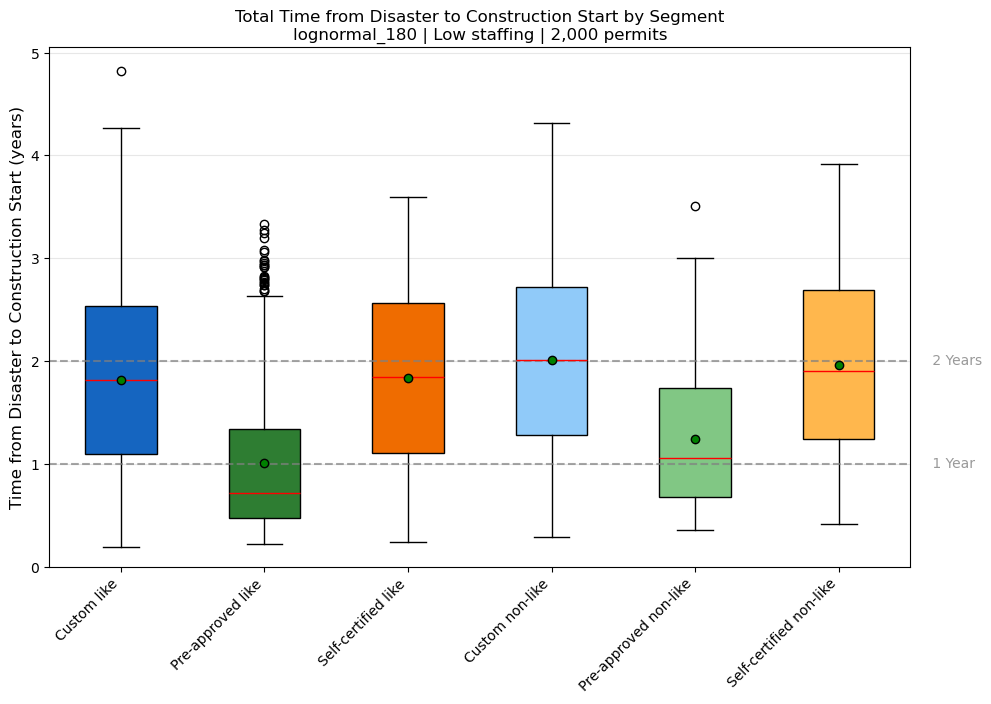

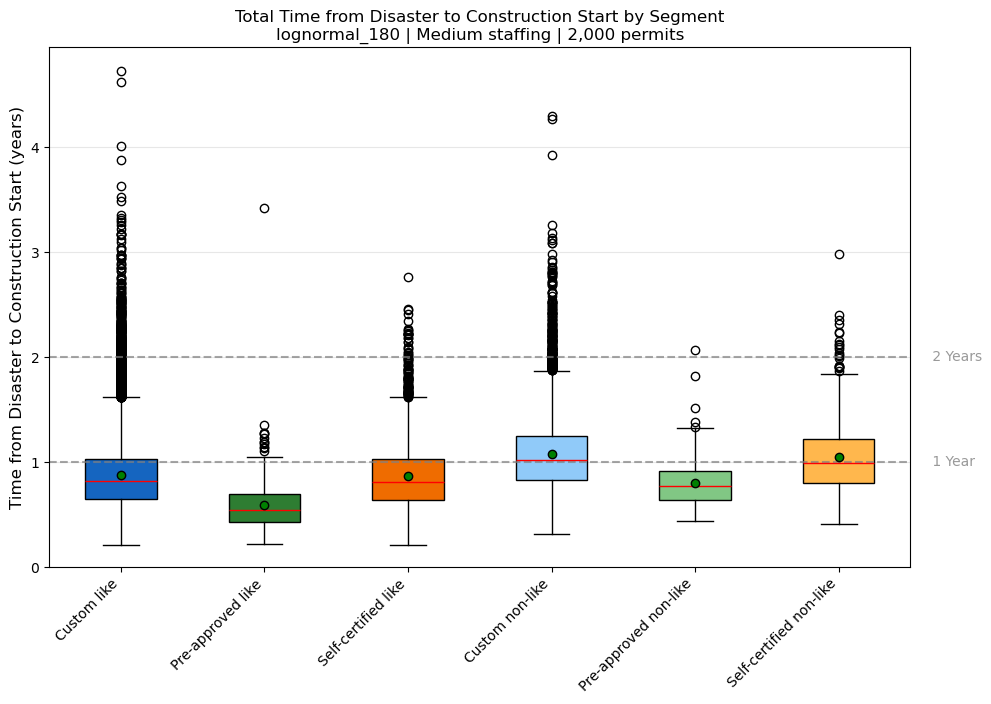

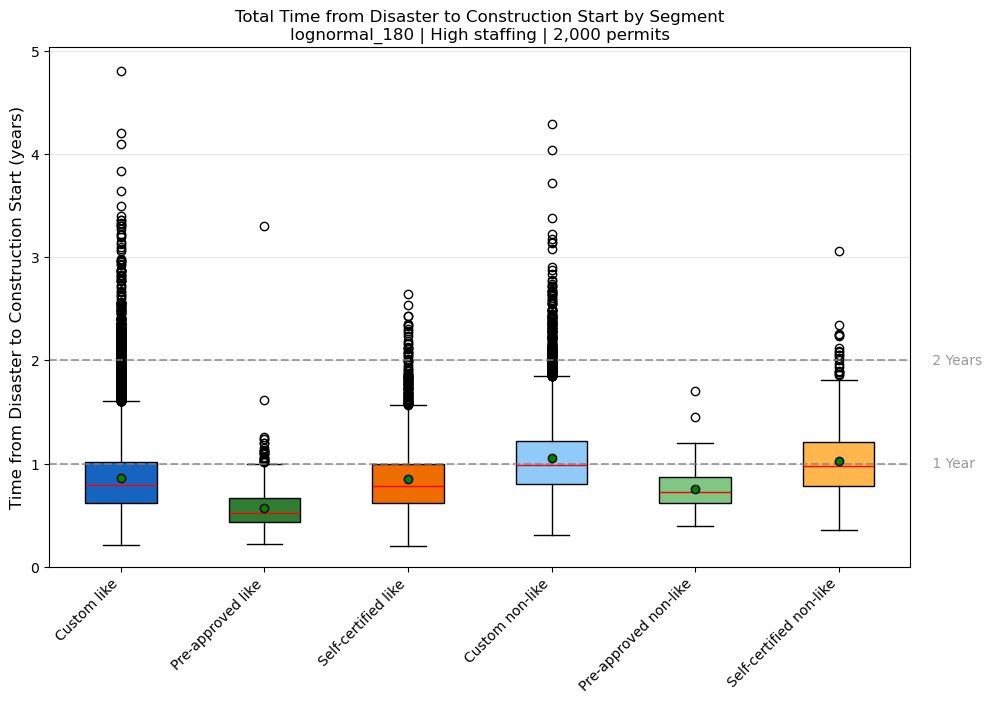

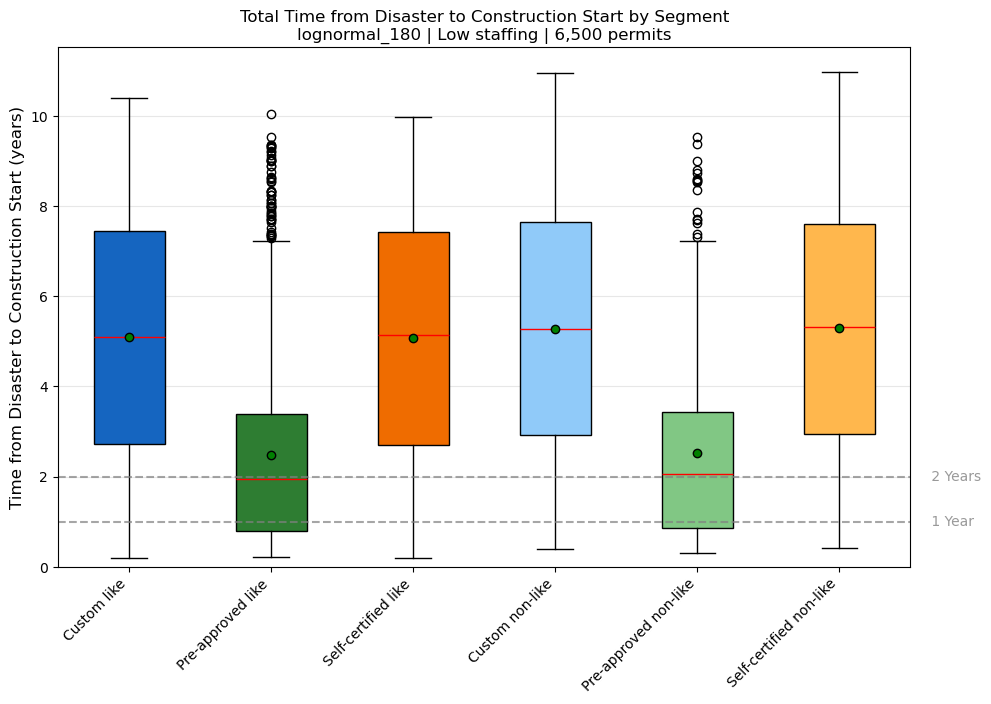

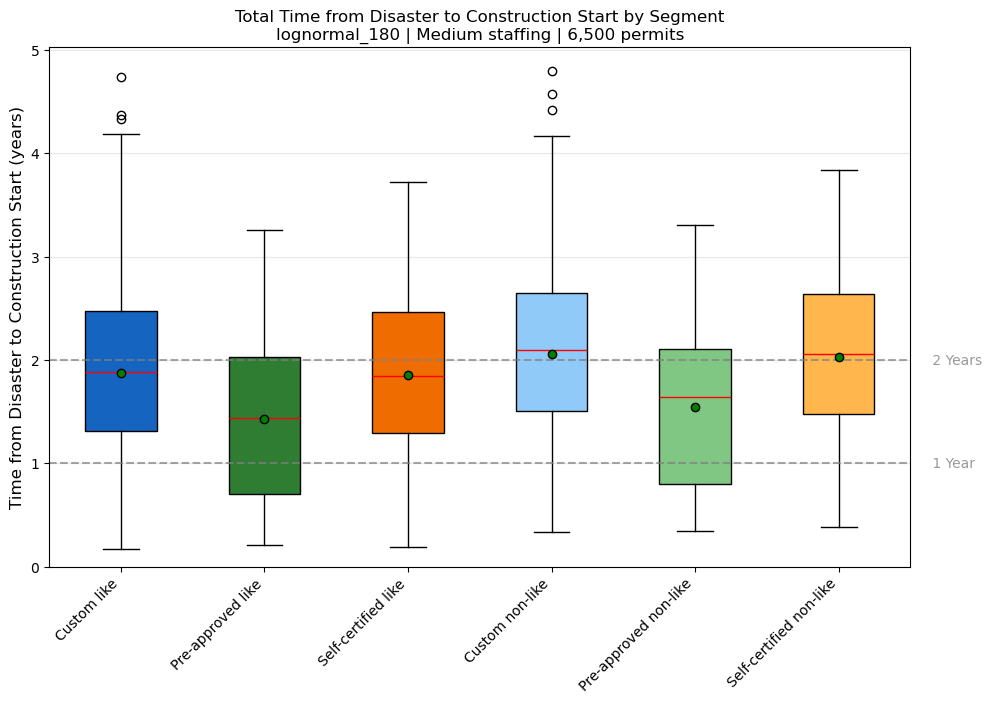

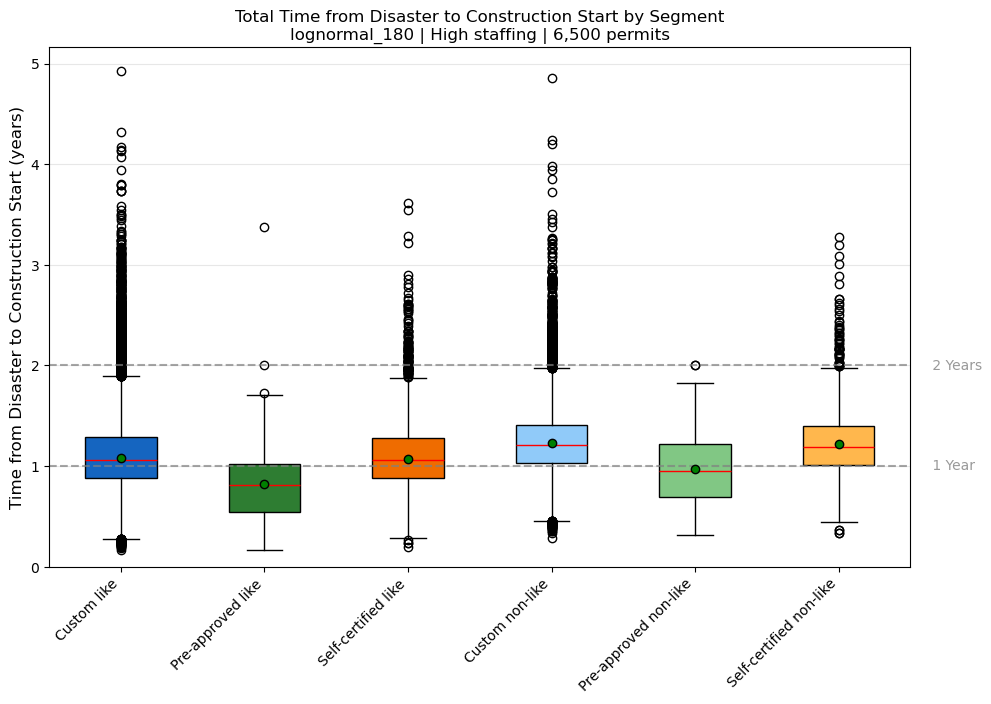

In [5]:
# Six-case segment boxplots: lognormal_180 only
# Cases = low/medium/high staffing x 2,000 and 6,500 permits

from run_simulation import run_multiple_simulations
from visualize_permits import plot_total_time_by_segment
import matplotlib.pyplot as plt

N_RUNS_CASES = 20
BASE_SEED_CASES = 42

PERMIT_COUNTS_CASES = [2000, 6500]
STAFFING_SCENARIOS_CASES = {
    "low": {"planning_staff_count": 2, "public_works_staff_count": 3, "fire_staff_count": 1},
    "medium": {"planning_staff_count": 8, "public_works_staff_count": 12, "fire_staff_count": 4},
    "high": {"planning_staff_count": 20, "public_works_staff_count": 30, "fire_staff_count": 10},
}

scenario_params_list_cases = []
for n in PERMIT_COUNTS_CASES:
    for staffing_name in ["low", "medium", "high"]:
        staffing = STAFFING_SCENARIOS_CASES[staffing_name]
        scenario_params_list_cases.append(
            {
                "name": f"permits={n}|staffing={staffing_name}",
                "num_permits": n,
                "sequential": "standard",
                "pre_application_distribution": "lognormal_180",
                **staffing,
            }
        )

multi_results_cases = run_multiple_simulations(
    n_runs=N_RUNS_CASES,
    num_permits=2000,  # overridden by each scenario's num_permits
    simulation_duration=None,
    base_seed=BASE_SEED_CASES,
    scenario_params_list=scenario_params_list_cases,
    collect_permits=True,
)

permits_by_case = {s["name"]: [] for s in scenario_params_list_cases}
for res in multi_results_cases:
    permits_by_case[res["scenario"]].extend(res.get("permits", []))

for n in PERMIT_COUNTS_CASES:
    for staffing_name in ["low", "medium", "high"]:
        case_name = f"permits={n}|staffing={staffing_name}"
        permits = permits_by_case.get(case_name, [])

        fig, ax = plot_total_time_by_segment(permits, figsize=(10, 7), show_boxplot=True)
        if ax is not None:
            ax.set_title(
                f"Total Time from Disaster to Construction Start by Segment\n"
                f"lognormal_180 | {staffing_name.title()} staffing | {n:,} permits",
                fontsize=12,
            )
            plt.show()
        else:
            print(f"No data to plot for {case_name}")

/var/folders/1l/bwjmhfhd57ddyrfdw7nl60kh0000gq/T/ipykernel_44881/2229004969.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(segment_times, patch_artist=True, labels=labels)


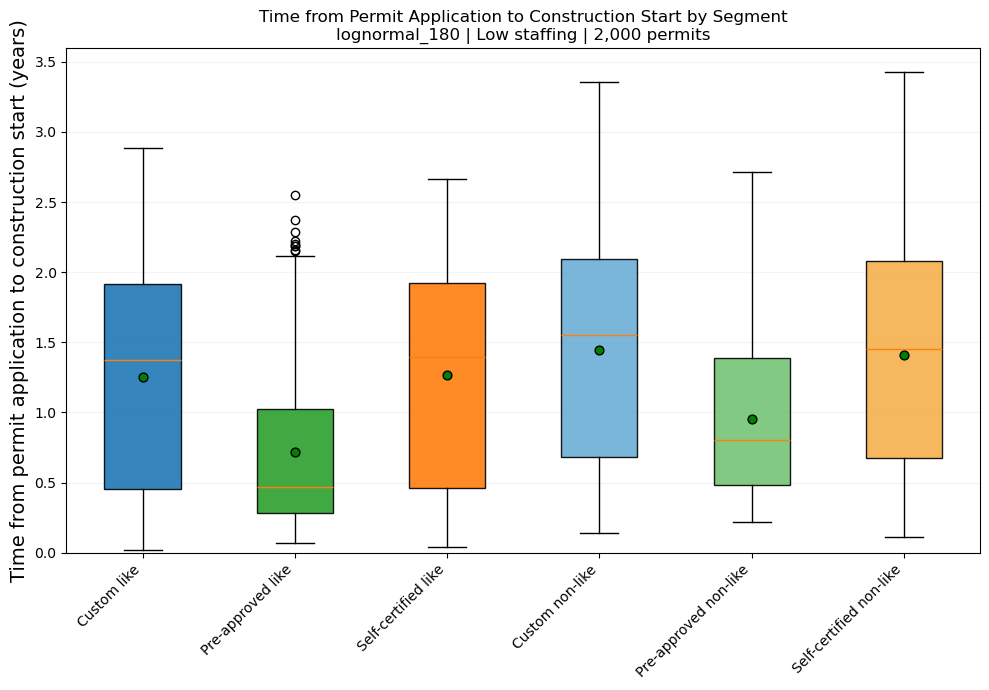

/var/folders/1l/bwjmhfhd57ddyrfdw7nl60kh0000gq/T/ipykernel_44881/2229004969.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(segment_times, patch_artist=True, labels=labels)


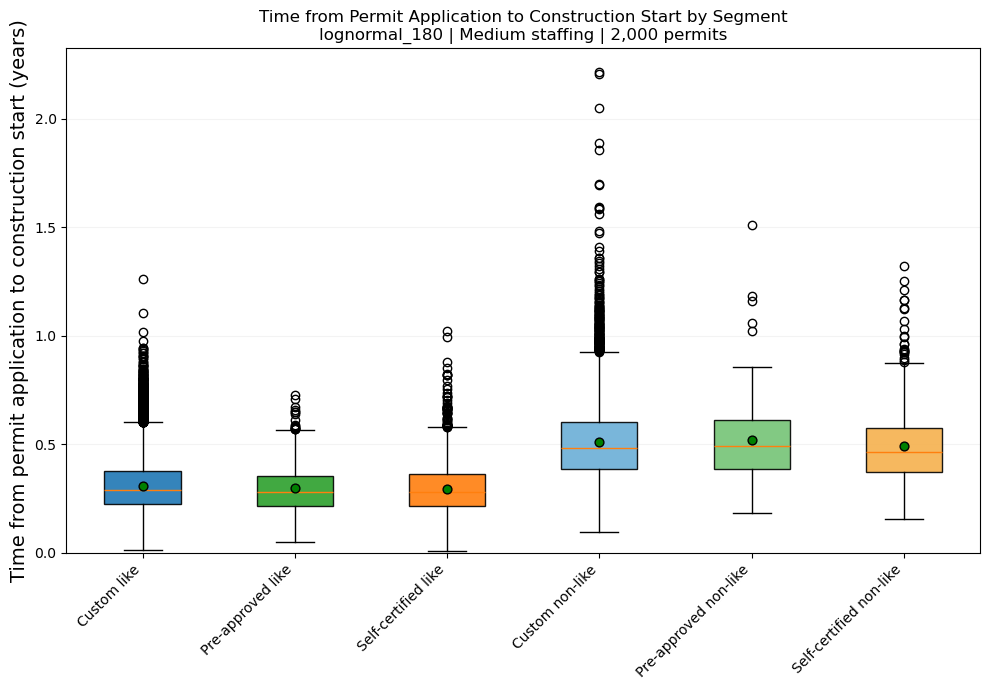

/var/folders/1l/bwjmhfhd57ddyrfdw7nl60kh0000gq/T/ipykernel_44881/2229004969.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(segment_times, patch_artist=True, labels=labels)


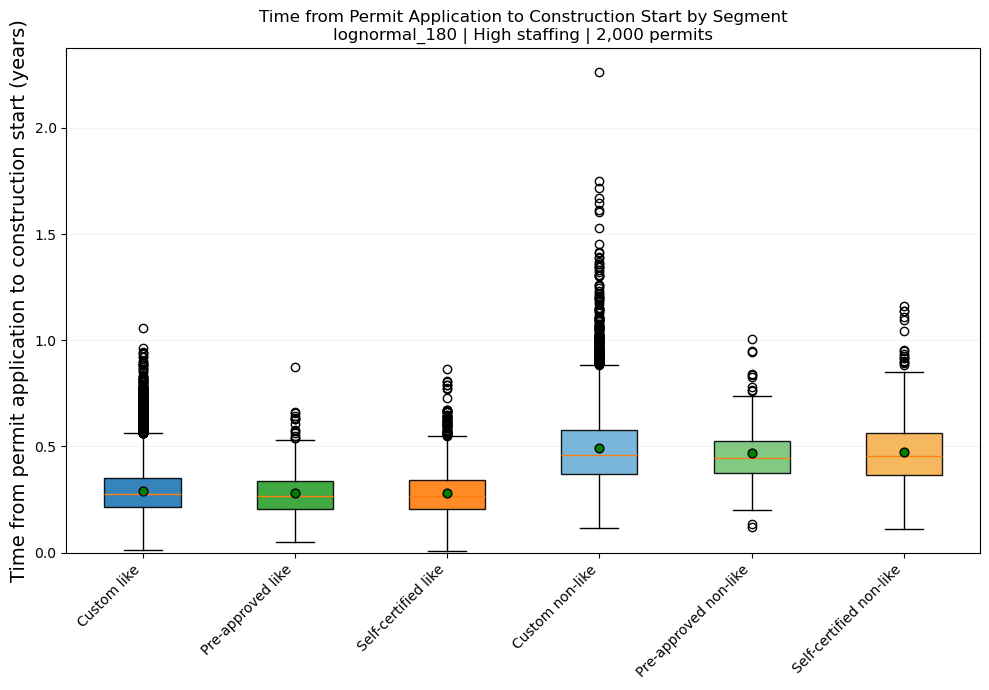

/var/folders/1l/bwjmhfhd57ddyrfdw7nl60kh0000gq/T/ipykernel_44881/2229004969.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(segment_times, patch_artist=True, labels=labels)


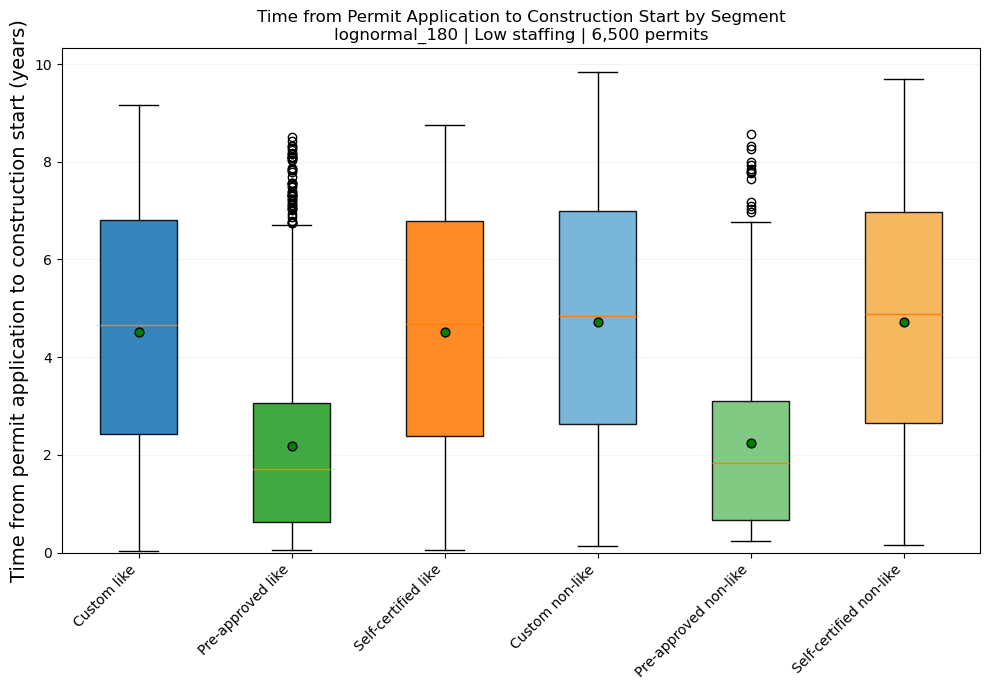

/var/folders/1l/bwjmhfhd57ddyrfdw7nl60kh0000gq/T/ipykernel_44881/2229004969.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(segment_times, patch_artist=True, labels=labels)


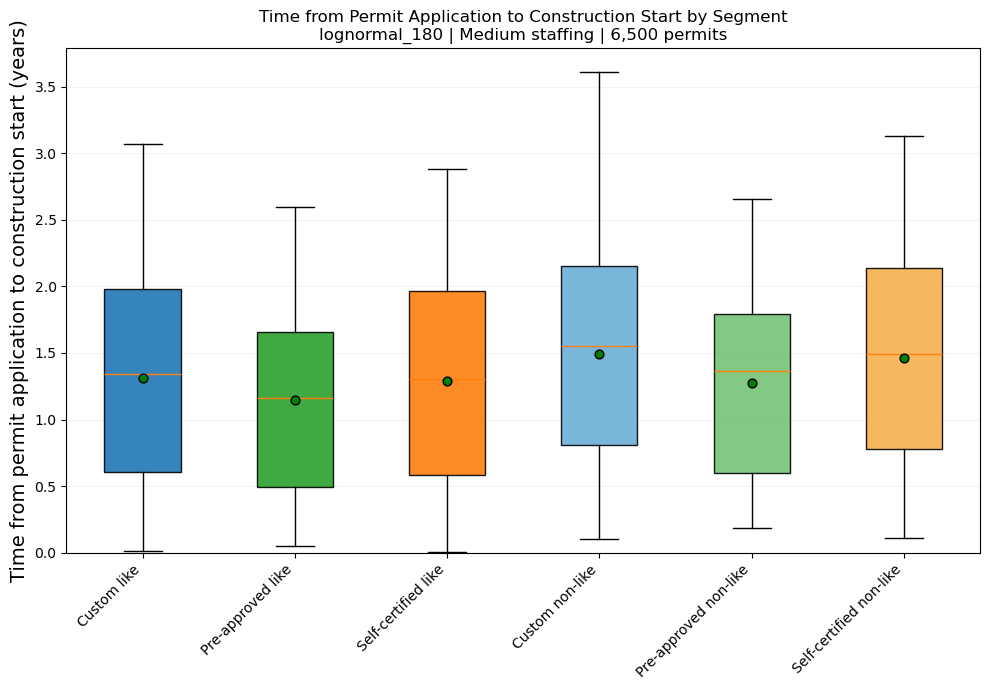

/var/folders/1l/bwjmhfhd57ddyrfdw7nl60kh0000gq/T/ipykernel_44881/2229004969.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(segment_times, patch_artist=True, labels=labels)


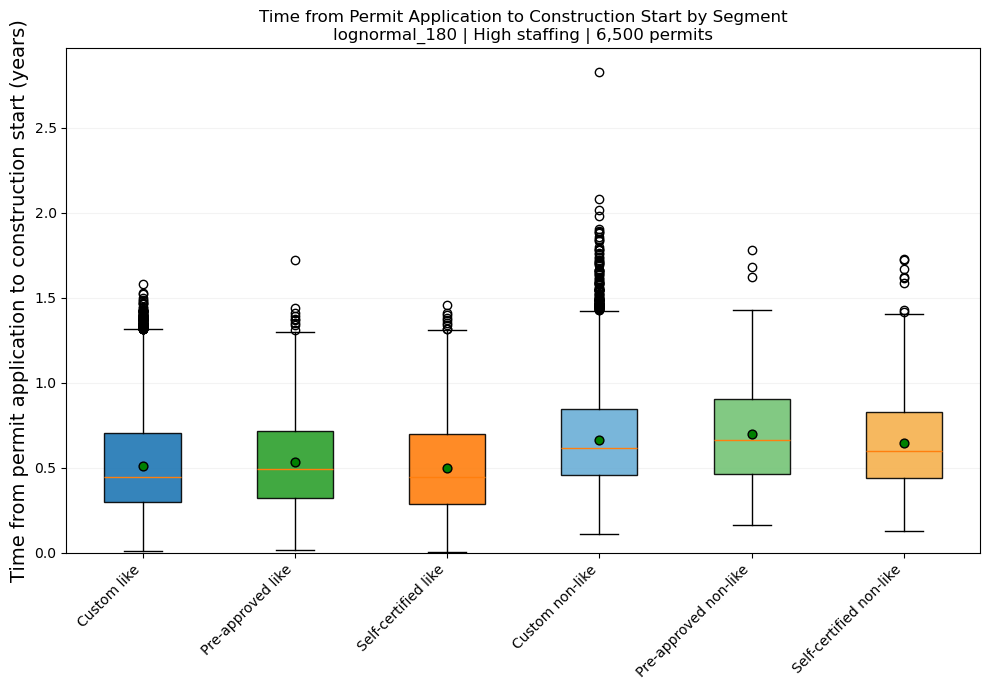

In [6]:
# Six-case segment boxplots: application -> construction start (lognormal_180)
# Expects `permits_by_case` from the prior six-case cell.

import numpy as np
import matplotlib.pyplot as plt
from permit_simulation import Segment
from simulation_plot_helpers import show_boxplot_stats_table

if "permits_by_case" not in dir():
    raise NameError("Run the previous six-case cell first to define permits_by_case.")

segment_order = [
    Segment.CUSTOM_LIKE,
    Segment.PRE_APPROVED_LIKE,
    Segment.SELF_CERT_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
]
label_by_segment = {
    Segment.PRE_APPROVED_LIKE: "Pre-approved like",
    Segment.PRE_APPROVED_NON_LIKE: "Pre-approved non-like",
    Segment.CUSTOM_LIKE: "Custom like",
    Segment.CUSTOM_NON_LIKE: "Custom non-like",
    Segment.SELF_CERT_LIKE: "Self-certified like",
    Segment.SELF_CERT_NON_LIKE: "Self-certified non-like",
}
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#6baed6", "#74c476", "#f6b14e"]

for n in [2000, 6500]:
    for staffing_name in ["low", "medium", "high"]:
        case_name = f"permits={n}|staffing={staffing_name}"
        permits = permits_by_case.get(case_name, [])

        segment_times = []
        labels = []
        for seg in segment_order:
            vals = [
                (p.ready_for_construction - p.planning_request) / 365.0
                for p in permits
                if p.segment == seg
                and p.ready_for_construction is not None
                and p.planning_request is not None
            ]
            if vals:
                segment_times.append(vals)
                labels.append(label_by_segment[seg])

        if not segment_times:
            print(f"No application-to-construction data for {case_name}")
            continue

        fig, ax = plt.subplots(figsize=(10, 7))
        bp = ax.boxplot(segment_times, patch_artist=True, labels=labels)
        for patch, color in zip(bp["boxes"], colors[: len(segment_times)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.9)

        for i, times in enumerate(segment_times, start=1):
            ax.scatter(i, float(np.mean(times)), color="green", s=40, edgecolor="black", zorder=3)

        ax.set_title(
            "Time from Permit Application to Construction Start by Segment\n"
            f"lognormal_180 | {staffing_name.title()} staffing | {n:,} permits",
            fontsize=12,
        )
        ax.set_ylabel("Time from permit application to construction start (years)", fontsize=14)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylim(bottom=0)
        ax.grid(True, axis="y", linestyle="-", alpha=0.15)

        plt.tight_layout()
        plt.show()


In [7]:
# Experiment: baseline vs balanced by scenario, then segment-level percent differences
# Baseline (per scenario): all permits are custom + non-like-for-like.
# Comparison run (same scenario settings): balanced segment distribution.
# Metric: time from permit application (planning_request) to ready for construction.

import numpy as np
import pandas as pd
from IPython.display import display
from run_simulation import run_multiple_simulations
from permit_simulation import Segment

_nruns = int(N_RUNS_CASES) if "N_RUNS_CASES" in globals() else 40
_seed = int(BASE_SEED_CASES) if "BASE_SEED_CASES" in globals() else 42

PERMIT_COUNTS_EXP = [2000, 6500]
STAFFING_SCENARIOS_EXP = {
    "low": {"planning_staff_count": 2, "public_works_staff_count": 3, "fire_staff_count": 1},
    "medium": {"planning_staff_count": 8, "public_works_staff_count": 12, "fire_staff_count": 4},
    "high": {"planning_staff_count": 20, "public_works_staff_count": 30, "fire_staff_count": 10},
}

base_scenarios = []
balanced_scenarios = []
for n in PERMIT_COUNTS_EXP:
    for staffing_name in ["low", "medium", "high"]:
        staffing = STAFFING_SCENARIOS_EXP[staffing_name]
        scenario_name = f"permits={n}|staffing={staffing_name}"

        common = {
            "name": scenario_name,
            "num_permits": n,
            "sequential": "standard",
            "pre_application_distribution": "lognormal_180",
            **staffing,
        }

        base_scenarios.append({**common, "permit_mix": "all_custom_non_like_for_like"})
        balanced_scenarios.append({**common, "permit_mix": "balanced"})

base_results = run_multiple_simulations(
    n_runs=_nruns,
    num_permits=2000,
    simulation_duration=None,
    base_seed=_seed,
    scenario_params_list=base_scenarios,
    collect_permits=True,
)

balanced_results = run_multiple_simulations(
    n_runs=_nruns,
    num_permits=2000,
    simulation_duration=None,
    base_seed=_seed,
    scenario_params_list=balanced_scenarios,
    collect_permits=True,
)

permits_base_by_case = {s["name"]: [] for s in base_scenarios}
for res in base_results:
    permits_base_by_case[res["scenario"]].extend(res.get("permits", []))

permits_balanced_by_case = {s["name"]: [] for s in balanced_scenarios}
for res in balanced_results:
    permits_balanced_by_case[res["scenario"]].extend(res.get("permits", []))

segment_order = [
    Segment.CUSTOM_LIKE,
    Segment.PRE_APPROVED_LIKE,
    Segment.SELF_CERT_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
]
label_by_segment = {
    Segment.CUSTOM_LIKE: "Custom, like-for-like",
    Segment.PRE_APPROVED_LIKE: "Pre-approved, like-for-like",
    Segment.SELF_CERT_LIKE: "Self-certified, like-for-like",
    Segment.CUSTOM_NON_LIKE: "Custom, non-like-for-like",
    Segment.PRE_APPROVED_NON_LIKE: "Pre-approved, non-like-for-like",
    Segment.SELF_CERT_NON_LIKE: "Self-certified, non-like-for-like",
}


def _app_to_ready_years(permit):
    if permit.ready_for_construction is None or permit.planning_request is None:
        return np.nan
    return (permit.ready_for_construction - permit.planning_request) / 365.0


scenario_diff_rows = []
segment_vs_custom_non_like_rows = []

for spec in base_scenarios:
    scenario_name = spec["name"]
    base_permits = permits_base_by_case.get(scenario_name, [])
    balanced_permits = permits_balanced_by_case.get(scenario_name, [])

    baseline_vals = [_app_to_ready_years(p) for p in base_permits]
    baseline_vals = [v for v in baseline_vals if not np.isnan(v)]
    baseline_mean = float(np.mean(baseline_vals)) if baseline_vals else np.nan

    balanced_vals = [_app_to_ready_years(p) for p in balanced_permits]
    balanced_vals = [v for v in balanced_vals if not np.isnan(v)]
    balanced_mean = float(np.mean(balanced_vals)) if balanced_vals else np.nan

    if np.isnan(baseline_mean) or baseline_mean == 0 or np.isnan(balanced_mean):
        pct_diff_vs_baseline = np.nan
    else:
        pct_diff_vs_baseline = (balanced_mean - baseline_mean) / baseline_mean * 100.0

    scenario_diff_rows.append(
        {
            "scenario": scenario_name,
            "baseline_mean_years": baseline_mean,
            "balanced_mean_years": balanced_mean,
            "mean_time_difference_years": (balanced_mean - baseline_mean) if not (np.isnan(baseline_mean) or np.isnan(balanced_mean)) else np.nan,
            "mean_time_difference_percent": pct_diff_vs_baseline,
        }
    )

    # Within each balanced scenario, compare each segment to custom non-like-for-like.
    segment_means = {}
    for seg in segment_order:
        seg_vals = [_app_to_ready_years(p) for p in balanced_permits if p.segment == seg]
        seg_vals = [v for v in seg_vals if not np.isnan(v)]
        segment_means[seg] = float(np.mean(seg_vals)) if seg_vals else np.nan

    ref = segment_means.get(Segment.CUSTOM_NON_LIKE, np.nan)
    row = {"scenario": scenario_name}
    for seg in segment_order:
        lbl = label_by_segment[seg]
        seg_mean = segment_means[seg]
        if np.isnan(ref) or ref == 0 or np.isnan(seg_mean):
            row[lbl] = np.nan
        else:
            row[lbl] = (seg_mean - ref) / ref * 100.0

    segment_vs_custom_non_like_rows.append(row)

scenario_diff_df = pd.DataFrame(scenario_diff_rows).set_index("scenario")
segment_vs_custom_non_like_df = pd.DataFrame(segment_vs_custom_non_like_rows).set_index("scenario")

print("Baseline = all custom non-like-for-like; comparison = balanced segment distribution.")
print(f"Runs per scenario = {_nruns}, base_seed = {_seed}")

print("\nTable 1: Scenario-level mean time difference (balanced vs baseline)\n")
display(
    scenario_diff_df.style.format(
        {
            "baseline_mean_years": "{:.3f}",
            "balanced_mean_years": "{:.3f}",
            "mean_time_difference_years": "{:+.3f}",
            "mean_time_difference_percent": "{:+.2f}%",
        },
        na_rep="—",
    )
)

print("\nTable 2: Segment matrix within balanced run, relative to Custom, non-like-for-like\n")
display(segment_vs_custom_non_like_df.style.format("{:+.2f}%", na_rep="—"))


Baseline = all custom non-like-for-like; comparison = balanced segment distribution.
Runs per scenario = 20, base_seed = 42

Table 1: Scenario-level mean time difference (balanced vs baseline)



,baseline_mean_years,balanced_mean_years,mean_time_difference_years,mean_time_difference_percent
scenario,,,,
permits=2000|staffing=low,2.093,1.304,-0.789,-37.70%
permits=2000|staffing=medium,0.633,0.344,-0.288,-45.58%
permits=2000|staffing=high,0.491,0.326,-0.165,-33.57%
permits=6500|staffing=low,6.541,4.557,-1.984,-30.33%
permits=6500|staffing=medium,1.907,1.321,-0.586,-30.74%
permits=6500|staffing=high,0.855,0.531,-0.324,-37.87%



Table 2: Segment matrix within balanced run, relative to Custom, non-like-for-like



,"Custom, like-for-like","Pre-approved, like-for-like","Self-certified, like-for-like","Custom, non-like-for-like","Pre-approved, non-like-for-like","Self-certified, non-like-for-like"
scenario,,,,,,
permits=2000|staffing=low,-12.19%,-40.01%,-11.24%,+0.00%,-26.51%,-0.98%
permits=2000|staffing=medium,-39.32%,-40.36%,-41.31%,+0.00%,-2.00%,-4.06%
permits=2000|staffing=high,-40.69%,-41.97%,-42.46%,+0.00%,-1.96%,-1.90%
permits=6500|staffing=low,-3.69%,-44.19%,-3.98%,+0.00%,-40.84%,+0.54%
permits=6500|staffing=medium,-13.01%,-10.94%,-13.55%,+0.00%,+1.94%,-0.53%
permits=6500|staffing=high,-25.12%,-12.48%,-26.36%,+0.00%,+13.32%,-2.24%


In [ ]:
# Box-and-whisker version: baseline vs expedited (balanced) permit mix
# Pooled application → ready times (months), all runs × all permits per scenario.
# Requires the baseline vs balanced experiment cell above.

import importlib
import matplotlib.pyplot as plt
import visualize_permits

importlib.reload(visualize_permits)
from visualize_permits import plot_expedited_baseline_app_to_ready_boxplots

_missing = [n for n in ("permits_base_by_case", "permits_balanced_by_case", "PERMIT_COUNTS_EXP") if n not in globals()]
if _missing:
    raise NameError("Run the experiment cell first (missing: " + ", ".join(_missing) + ")")

fig, ax = plot_expedited_baseline_app_to_ready_boxplots(
    permits_base_by_case,
    permits_balanced_by_case,
    permit_counts=PERMIT_COUNTS_EXP,
    staffing_order=("low", "medium", "high"),
)
if fig is not None:
    plt.show()


In [ ]:
# Statistical check: are segment differences vs custom non-like mostly noise?
# Uses scenario-level means (one mean per run) to estimate uncertainty.

import numpy as np
import pandas as pd
from scipy import stats

ref_seg = Segment.CUSTOM_NON_LIKE

def _app_to_ready_years(p):
    # Match earlier experiment metric: permit application (planning_request) -> ready.
    if p.ready_for_construction is None or p.planning_request is None:
        return np.nan
    return (p.ready_for_construction - p.planning_request) / 365.0

rows = []

# Build scenario -> list[run_permits] from whichever variable is available.
balanced_results_by_name = {}
if "balanced_results" in globals():
    for res in balanced_results:
        balanced_results_by_name.setdefault(res["scenario"], []).append(res.get("permits", []))
elif "permits_balanced_by_case" in globals() and "base_scenarios" in globals():
    # Fallback when only pooled permits exist: treat as one synthetic run per scenario.
    for spec in base_scenarios:
        name = spec["name"]
        balanced_results_by_name[name] = [permits_balanced_by_case.get(name, [])]
else:
    raise NameError(
        "Need `balanced_results` (from prior experiment cell) or `permits_balanced_by_case` + `base_scenarios`."
    )

for scenario_name, run_lists in balanced_results_by_name.items():
    # Collect per-run means by segment to avoid overconfident CIs from pooled permits.
    per_run_means = {seg: [] for seg in segment_order}
    per_run_counts = {seg: [] for seg in segment_order}

    for permits in run_lists:
        for seg in segment_order:
            vals = [_app_to_ready_years(p) for p in permits if p.segment == seg]
            vals = [v for v in vals if not np.isnan(v)]
            if vals:
                per_run_means[seg].append(float(np.mean(vals)))
                per_run_counts[seg].append(len(vals))

    ref_vals = np.array(per_run_means.get(ref_seg, []), dtype=float)
    ref_label = label_by_segment[ref_seg]

    for seg in segment_order:
        seg_vals = np.array(per_run_means.get(seg, []), dtype=float)
        n_runs_seg = int(seg_vals.size)
        if n_runs_seg == 0:
            continue

        seg_label = label_by_segment[seg]
        seg_mean = float(np.mean(seg_vals))
        seg_std = float(np.std(seg_vals, ddof=1)) if n_runs_seg > 1 else np.nan
        seg_se = seg_std / np.sqrt(n_runs_seg) if n_runs_seg > 1 else np.nan

        if n_runs_seg > 1:
            tcrit = float(stats.t.ppf(0.975, n_runs_seg - 1))
            ci_lo = seg_mean - tcrit * seg_se
            ci_hi = seg_mean + tcrit * seg_se
        else:
            ci_lo = np.nan
            ci_hi = np.nan

        avg_seg_count_per_run = float(np.mean(per_run_counts[seg])) if per_run_counts[seg] else np.nan

        diff_vs_ref_pct = np.nan
        p_value_vs_ref = np.nan
        if seg != ref_seg and ref_vals.size > 1 and seg_vals.size > 1:
            ref_mean = float(np.mean(ref_vals))
            if ref_mean != 0:
                diff_vs_ref_pct = (seg_mean - ref_mean) / ref_mean * 100.0
            _, p_value_vs_ref = stats.ttest_ind(seg_vals, ref_vals, equal_var=False)

        rows.append(
            {
                "scenario": scenario_name,
                "segment": seg_label,
                "n_runs_with_segment": n_runs_seg,
                "avg_permit_count_per_run": avg_seg_count_per_run,
                "mean_years": seg_mean,
                "std_across_run_means": seg_std,
                "ci95_low_years": ci_lo,
                "ci95_high_years": ci_hi,
                f"diff_vs_{ref_label}_pct": diff_vs_ref_pct,
                f"welch_p_vs_{ref_label}": p_value_vs_ref,
            }
        )

ci_df = pd.DataFrame(rows)
ci_df = ci_df.sort_values(["scenario", "segment"]).reset_index(drop=True)

print("Per-scenario segment uncertainty (run-level means; 95% CI)")
print("Tip: focus on avg_permit_count_per_run and p-values for pre-approved non-like.")

display(
    ci_df.style.format(
        {
            "avg_permit_count_per_run": "{:.1f}",
            "mean_years": "{:.3f}",
            "std_across_run_means": "{:.3f}",
            "ci95_low_years": "{:.3f}",
            "ci95_high_years": "{:.3f}",
            f"diff_vs_{ref_label}_pct": "{:+.2f}%",
            f"welch_p_vs_{ref_label}": "{:.4f}",
        },
        na_rep="—",
    )
)

Per-scenario segment uncertainty (run-level means; 95% CI)
Tip: focus on avg_permit_count_per_run and p-values for pre-approved non-like.


,scenario,segment,n_runs_with_segment,avg_permit_count_per_run,mean_years,std_across_run_means,ci95_low_years,ci95_high_years,"diff_vs_Custom, non-like-for-like_pct","welch_p_vs_Custom, non-like-for-like"
0,permits=2000|staffing=high,"Custom, like-for-like",20,800.9,0.290,0.003,0.288,0.292,-40.71%,0.0000
1,permits=2000|staffing=high,"Custom, non-like-for-like",20,200.8,0.489,0.017,0.481,0.497,—,—
2,permits=2000|staffing=high,"Pre-approved, like-for-like",20,393.6,0.284,0.004,0.282,0.286,-42.00%,0.0000
3,permits=2000|staffing=high,"Pre-approved, non-like-for-like",20,102.5,0.479,0.017,0.471,0.486,-2.16%,0.0521
4,permits=2000|staffing=high,"Self-certified, like-for-like",20,404.5,0.281,0.004,0.279,0.283,-42.50%,0.0000
5,permits=2000|staffing=high,"Self-certified, non-like-for-like",20,97.8,0.480,0.019,0.471,0.489,-1.91%,0.1074
6,permits=2000|staffing=low,"Custom, like-for-like",20,800.9,1.370,0.028,1.357,1.383,-12.16%,0.0000
7,permits=2000|staffing=low,"Custom, non-like-for-like",20,200.8,1.560,0.054,1.534,1.585,—,—
8,permits=2000|staffing=low,"Pre-approved, like-for-like",20,393.6,0.935,0.039,0.917,0.954,-40.03%,0.0000
9,permits=2000|staffing=low,"Pre-approved, non-like-for-like",20,102.5,1.146,0.048,1.124,1.168,-26.52%,0.0000
